In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import torch
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

1. 形状 3x4 的随机矩阵 X，标准正态分布

In [2]:
np.random.seed(42)
X = np.random.rand(3, 4)

2. 形状 4x2 的全 1 矩阵 Y

In [3]:
Y = np.ones((4, 2))

3. 矩阵乘法 Z = X @ Y

In [4]:
Z = X @ Y

4. 输出 Z 的第一行和第二列交叉处的元素（索引：第0行，第1列）

In [5]:
elem = Z[0, 1]

5. 输出 Z 的第 2 行所有元素（索引：第1行）

In [6]:
row_2 = Z[1, :]
print("X:\n", X)
print("Y:\n", Y)
print("Z:\n", Z)
print("Z[0, 1] (第1行第2列):", elem)
print("Z 的第2行:", row_2)

X:
 [[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]]
Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z:
 [[2.65590685 2.65590685]
 [1.23627292 1.23627292]
 [2.29968194 2.29968194]]
Z[0, 1] (第1行第2列): 2.6559068512657205
Z 的第2行: [1.23627292 1.23627292]


5. 计算 Z 的 Frobenius 范数

In [7]:
fro_norm = np.linalg.norm(Z, 'fro')
print("Frobenius 范数:", fro_norm)

Frobenius 范数: 5.267019828881641


6. 模拟中心极限定理

In [8]:
n=10000
m=1000
np.random.seed(42)
sample_means = []
for _ in range(m):
    samples = np.random.uniform(0, 1, n)   # 生成 n 个 U(0,1) 样本
    sample_means.append(np.mean(samples))  # 计算均值并记录

sample_means = np.array(sample_means)

mu_theory = 0.5                          # U(0,1) 的理论均值
sigma_theory = np.sqrt(1/12)             # U(0,1) 的理论标准差
mu_sample_mean = mu_theory
std_sample_mean = sigma_theory / np.sqrt(n)

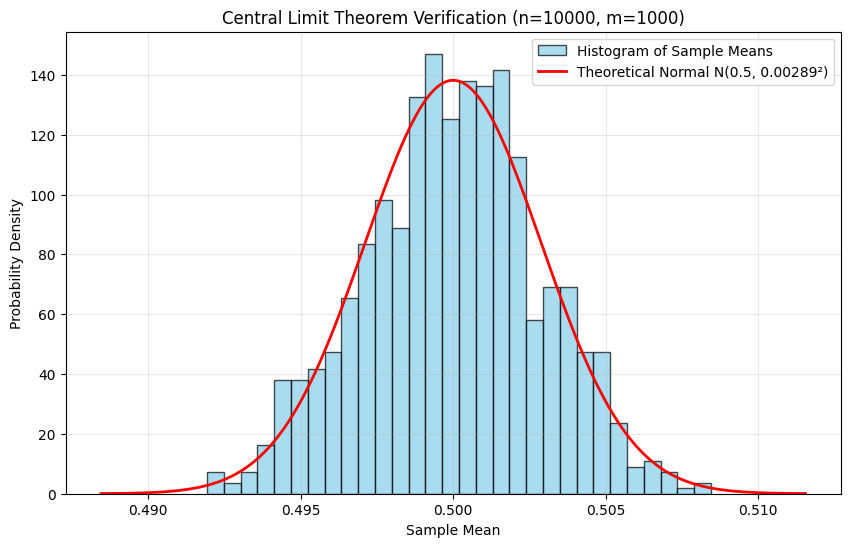

In [9]:
plt.figure(figsize=(10, 6))
count, bins, _ = plt.hist(sample_means, bins=30, density=True, alpha=0.7, 
                          color='skyblue', edgecolor='black', label='Histogram of Sample Means')
# 叠加理论正态分布曲线
x = np.linspace(mu_sample_mean - 4*std_sample_mean, 
                mu_sample_mean + 4*std_sample_mean, 200)
y = norm.pdf(x, mu_sample_mean, std_sample_mean)
plt.plot(x, y, 'r-', linewidth=2, label=f'Theoretical Normal N({mu_sample_mean}, {std_sample_mean:.5f}²)')

plt.xlabel('Sample Mean')
plt.ylabel('Probability Density')
plt.title(f'Central Limit Theorem Verification (n={n}, m={m})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
actual_var = np.var(sample_means, ddof=0)   # 总体方差（除以 m）
actual_std = np.std(sample_means, ddof=0)

print(f"理论样本均值的方差: {std_sample_mean**2:.8f}")
print(f"实际计算出的样本均值的方差: {actual_var:.8f}")
print(f"实际标准差: {actual_std:.6f}")
print(f"理论标准差: {std_sample_mean:.6f}")

理论样本均值的方差: 0.00000833
实际计算出的样本均值的方差: 0.00000828
实际标准差: 0.002877
理论标准差: 0.002887


7. 简单计算图的反向传播

In [11]:
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

a = x * w1
b = a + w2
L = b ** 2

L.backward()

print(f"手动计算的 dL/dw1 = 14, PyTorch 结果: {w1.grad.item()}")
print(f"手动计算的 dL/dw2 = 7, PyTorch 结果: {w2.grad.item()}")

手动计算的 dL/dw1 = 14, PyTorch 结果: 14.0
手动计算的 dL/dw2 = 7, PyTorch 结果: 7.0


8. softmax 回归对手写数字（MNIST）进行分类

In [12]:
digits = load_digits()
X = digits.images  # (1797, 8, 8)
y = digits.target  # (1797,)

X = X.reshape(X.shape[0], -1)  # (1797, 64)

X = X / 16.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

enc = OneHotEncoder(sparse_output=False)
y_train_onehot = enc.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = enc.transform(y_test.reshape(-1, 1))
num_classes = y_train_onehot.shape[1]

def softmax(z):
    """z: (batch_size, num_classes)"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 数值稳定性
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """y_pred: softmax 输出, y_true: one-hot"""
    batch_size = y_pred.shape[0]
    # 避免 log(0)
    eps = 1e-12
    loss = -np.sum(y_true * np.log(y_pred + eps)) / batch_size
    return loss

input_size = X_train.shape[1]   # 64
output_size = num_classes        # 10
learning_rate = 0.1
batch_size = 32
epochs = 50

W = np.random.randn(input_size, output_size) * 0.01
b = np.zeros((1, output_size))

for epoch in range(epochs):
    # 打乱训练数据
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0.0
    num_batches = 0
    
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = np.dot(X_batch, W) + b   # (batch_size, 10)
        probs = softmax(logits)
        
        # 损失
        loss = cross_entropy_loss(probs, y_batch)
        epoch_loss += loss
        num_batches += 1
        
        # 反向传播（梯度）
        batch_size_actual = X_batch.shape[0]
        dlogits = probs - y_batch                 # (batch_size, 10)
        dW = np.dot(X_batch.T, dlogits) / batch_size_actual
        db = np.sum(dlogits, axis=0, keepdims=True) / batch_size_actual
        
        # 参数更新
        W -= learning_rate * dW
        b -= learning_rate * db
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/num_batches:.6f}")

def predict(X, W, b):
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)

y_pred = predict(X_test, W, b)
y_true = y_test

accuracy = np.mean(y_pred == y_true)
print(f"\n测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

Epoch 10/50, Loss: 0.454398
Epoch 20/50, Loss: 0.298268
Epoch 30/50, Loss: 0.238268
Epoch 40/50, Loss: 0.204537
Epoch 50/50, Loss: 0.182895

测试集准确率: 0.9528 (95.28%)


9. 二分类逻辑回归模型

In [18]:
np.random.seed(42)

def generate_linear_data(n_samples=200, n_features=2):
    """生成线性可分的二分类数据"""
    X0 = np.random.randn(n_samples, n_features) + np.array([-1.5, -1.5])
    y0 = np.zeros(n_samples)
    
    X1 = np.random.randn(n_samples, n_features) + np.array([1.5, 1.5])
    y1 = np.ones(n_samples)
    
    X = np.vstack([X0, X1])
    y = np.hstack([y0, y1])
    
    return X, y

# 为逻辑回归单独构造二分类数据，并划分训练/测试集
X_bin, y_bin = generate_linear_data(n_samples=200)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print(f"训练集形状: {X_train_bin.shape}, 标签形状: {y_train_bin.shape}")
print(f"测试集形状: {X_test_bin.shape}, 标签形状: {y_test_bin.shape}")

def sigmoid(z):
    """Sigmoid 函数"""
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    """二元交叉熵损失"""
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def predict_proba(X, w, b):
    """预测概率"""
    z = np.dot(X, w) + b
    return sigmoid(z)

def predict(X, w, b, threshold=0.5):
    """预测类别"""
    proba = predict_proba(X, w, b)
    return (proba >= threshold).astype(int)

训练集形状: (320, 2), 标签形状: (320,)
测试集形状: (80, 2), 标签形状: (80,)


In [19]:
def train_logistic_regression(X, y, learning_rate=0.1, n_iterations=1000, verbose=True):
    """使用梯度下降训练逻辑回归模型"""
    n_samples, n_features = X.shape
    
    # 初始化参数
    w = np.zeros(n_features)
    b = 0.0
    
    losses = []
    
    for i in range(n_iterations):
        # 前向传播：计算预测值
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        
        # 计算损失
        loss = binary_cross_entropy(y_pred, y)
        losses.append(loss)
        
        # 计算梯度
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)
        
        # 更新参数
        w -= learning_rate * dw
        b -= learning_rate * db
        
        # 打印进度
        if verbose and (i + 1) % 200 == 0:
            print(f"Iteration {i+1}/{n_iterations}, Loss: {loss:.6f}")
    
    return w, b, losses

In [21]:
print("\n开始训练...")
w, b, losses = train_logistic_regression(X_train_bin, y_train_bin, 
                                          learning_rate=0.1, 
                                          n_iterations=1000)

print(f"\n训练完成!")
print(f"最终权重 w: {w}")
print(f"最终偏置 b: {b:.6f}")


开始训练...
Iteration 200/1000, Loss: 0.065237
Iteration 400/1000, Loss: 0.053789
Iteration 600/1000, Loss: 0.049338
Iteration 800/1000, Loss: 0.046928
Iteration 1000/1000, Loss: 0.045416

训练完成!
最终权重 w: [2.53511846 2.16719662]
最终偏置 b: 0.055684


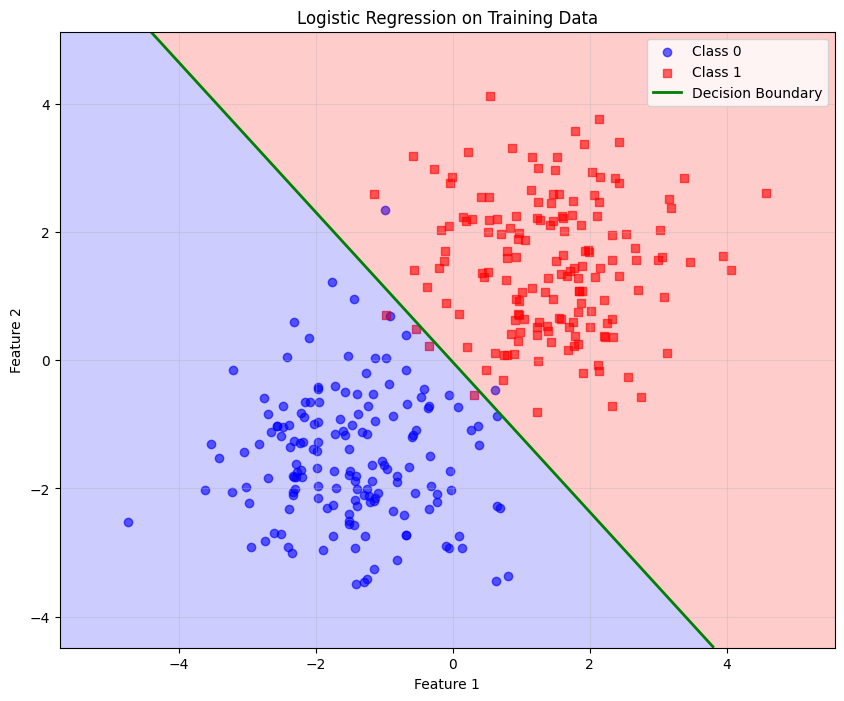

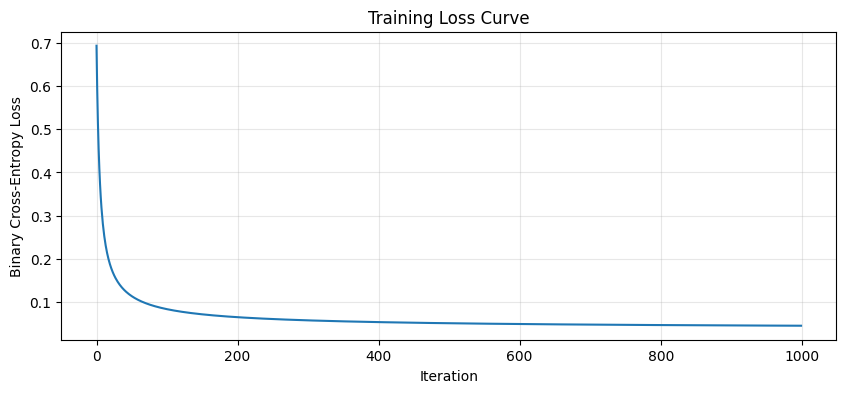

In [22]:
def plot_decision_boundary(X, y, w, b, title="Logistic Regression Decision Boundary"):
    """绘制数据点和决策边界"""
    plt.figure(figsize=(10, 8))
    
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', label='Class 0', alpha=0.6)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', label='Class 1', alpha=0.6)
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = predict_proba(np.c_[xx.ravel(), yy.ravel()], w, b)
    Z = Z.reshape(xx.shape)
    
    plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)
    plt.plot([], [], color='green', linewidth=2, label='Decision Boundary')
    plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    plt.figure(figsize=(10, 4))
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Binary Cross-Entropy Loss')
    plt.title('Training Loss Curve')
    plt.grid(alpha=0.3)
    plt.show()
    
    return x_min, x_max, y_min, y_max

x_min, x_max, y_min, y_max = plot_decision_boundary(X_train_bin, y_train_bin, w, b, 
                                                     "Logistic Regression on Training Data")


测试集评估(80个样本):
测试集准确率: 1.0000 (100.00%)

分类报告:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        40
     Class 1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

混淆矩阵:
[[40  0]
 [ 0 40]]


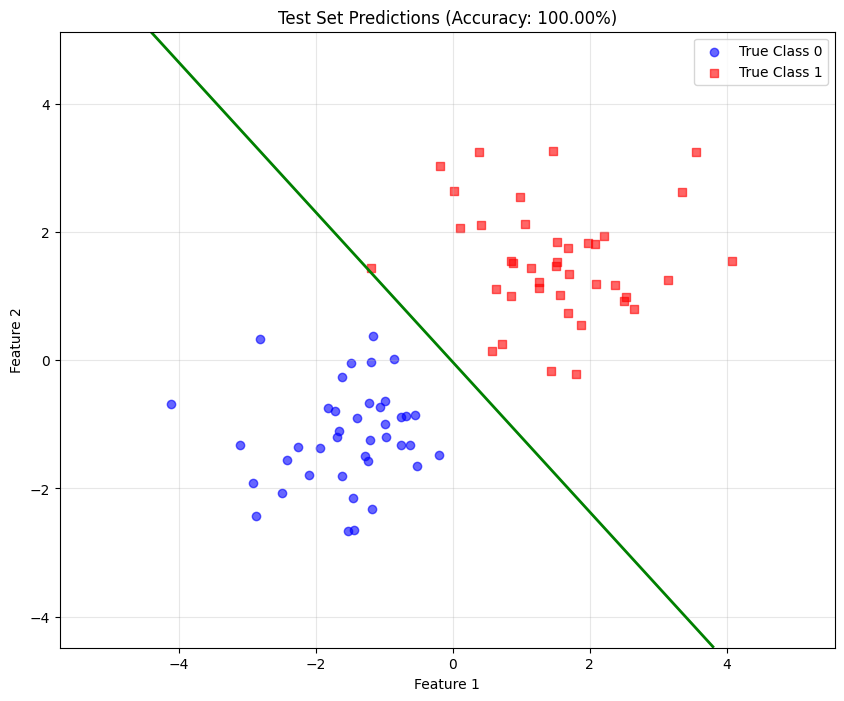

In [23]:
# 在测试集上预测
y_pred_test = predict(X_test_bin, w, b)
accuracy = np.mean(y_pred_test == y_test_bin)

print(f"\n测试集评估({X_test_bin.shape[0]}个样本):")
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n分类报告:")
print(classification_report(y_test_bin, y_pred_test, target_names=['Class 0', 'Class 1']))

print("混淆矩阵:")
print(confusion_matrix(y_test_bin, y_pred_test))

plt.figure(figsize=(10, 8))
plt.scatter(X_test_bin[y_test_bin==0, 0], X_test_bin[y_test_bin==0, 1], c='blue', marker='o', 
            label='True Class 0', alpha=0.6)
plt.scatter(X_test_bin[y_test_bin==1, 0], X_test_bin[y_test_bin==1, 1], c='red', marker='s', 
            label='True Class 1', alpha=0.6)

misclassified = y_pred_test != y_test_bin
if np.any(misclassified):
    plt.scatter(X_test_bin[misclassified, 0], X_test_bin[misclassified, 1], 
                c='yellow', marker='x', s=200, linewidths=3, 
                label='Misclassified', alpha=0.8)

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = predict_proba(np.c_[xx.ravel(), yy.ravel()], w, b)
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='green', linewidths=2)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Test Set Predictions (Accuracy: {accuracy:.2%})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()